# Leave-Out Experiment: Remove Lifestyle Features

**CS 1675 - Introduction to Machine Learning**

This notebook trains three models **without Lifestyle features** to predict diabetes, then evaluates:
1. Overall performance metrics (accuracy, precision, recall, F1, ROC-AUC)
2. Feature importance for each model
3. Fairness across demographic groups (Race, Sex, Age)

**Features removed:** Smoker, PhysActivity, Fruits, Veggies, HvyAlcoholConsump

---

## 1. Setup and Data Loading

Import required libraries and load the preprocessed train/val/test splits.

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn models and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance

# PyTorch for neural network
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load the preprocessed data splits
# These were created in eda_and_preprocessing.ipynb with stratified 70/15/15 split
# Continuous features (BMI, MentHlth, PhysHlth) are already standardized

train = pd.read_csv('data/processed/train.csv')
val = pd.read_csv('data/processed/val.csv')
test = pd.read_csv('data/processed/test.csv')

print(f"Training set: {train.shape[0]:,} rows, {train.shape[1]} columns")
print(f"Validation set: {val.shape[0]:,} rows")
print(f"Test set: {test.shape[0]:,} rows")
print(f"\nColumns: {list(train.columns)}")

Training set: 176,026 rows, 23 columns
Validation set: 37,720 rows
Test set: 37,721 rows

Columns: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Race', 'Diabetes_binary']


In [3]:
# Define target variable name for use throughout notebook
TARGET = 'Diabetes_binary'

print(f"Target variable: {TARGET}")
print(f"Number of features: {train.shape[1] - 1}")

Target variable: Diabetes_binary
Number of features: 22


In [4]:
# Check class distribution - we have ~5.4:1 imbalance
# This is why we'll use class_weight='balanced' in our models

train_pos_rate = train[TARGET].mean()
val_pos_rate = val[TARGET].mean()
test_pos_rate = test[TARGET].mean()

print("Class distribution (positive = diabetes/prediabetes):")
print(f"  Train: {train_pos_rate:.1%} positive ({train[TARGET].sum():,} / {len(train):,})")
print(f"  Val:   {val_pos_rate:.1%} positive ({val[TARGET].sum():,} / {len(val):,})")
print(f"  Test:  {test_pos_rate:.1%} positive ({test[TARGET].sum():,} / {len(test):,})")
print(f"\nImbalance ratio: {(1-train_pos_rate)/train_pos_rate:.1f}:1 (negative:positive)")

Class distribution (positive = diabetes/prediabetes):
  Train: 15.7% positive (27,697.0 / 176,026)
  Val:   15.7% positive (5,935.0 / 37,720)
  Test:  15.7% positive (5,935.0 / 37,721)

Imbalance ratio: 5.4:1 (negative:positive)


## 2. Data Preparation

**One-hot encoding for Race**

Race is a nominal variable with 8 categories (no natural ordering). Different models handle this differently:
- **Logistic Regression & Neural Network**: Need one-hot encoding (7 dummy columns, dropping first to avoid multicollinearity)
- **Random Forest**: Can use integer encoding directly (trees split on thresholds)

We create a helper function to prepare features appropriately for each model type.

In [5]:
# Features to remove for this leave-out experiment
LIFESTYLE_FEATURES = ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']

def prepare_features(df, one_hot_race=False):
    """
    Prepare features and target from a dataframe.
    
    Args:
        df: DataFrame with all features and target
        one_hot_race: If True, convert Race to 7 dummy columns (for LR/NN)
                      If False, keep Race as integer 1-8 (for RF)
    
    Returns:
        X: Feature DataFrame
        y: Target Series
    """
    # Separate features and target
    X = df.drop(columns=[TARGET]).copy()
    y = df[TARGET].copy()
    
    # Remove lifestyle features for this experiment
    X = X.drop(columns=LIFESTYLE_FEATURES)
    
    if one_hot_race:
        # Create dummy variables for Race (drop_first=True to avoid multicollinearity)
        # This creates columns Race_2, Race_3, ..., Race_8 (Race_1 is the reference)
        race_dummies = pd.get_dummies(X['Race'], prefix='Race', drop_first=True)
        X = X.drop(columns=['Race'])
        X = pd.concat([X, race_dummies], axis=1)
    
    return X, y

# Prepare data for each model type
# LR and NN use one-hot encoding; RF uses integer encoding

# For Logistic Regression and Neural Network (one-hot Race)
X_train_oh, y_train = prepare_features(train, one_hot_race=True)
X_val_oh, y_val = prepare_features(val, one_hot_race=True)
X_test_oh, y_test = prepare_features(test, one_hot_race=True)

# For Random Forest (integer Race)
X_train_int, _ = prepare_features(train, one_hot_race=False)
X_val_int, _ = prepare_features(val, one_hot_race=False)
X_test_int, _ = prepare_features(test, one_hot_race=False)

print(f"Lifestyle features removed: {LIFESTYLE_FEATURES}")
print(f"\nOne-hot encoded features (for LR/NN):")
print(f"  Shape: {X_train_oh.shape} ({X_train_oh.shape[1]} features)")
print(f"  Columns: {list(X_train_oh.columns)}")
print(f"\nInteger encoded features (for RF):")
print(f"  Shape: {X_train_int.shape} ({X_train_int.shape[1]} features)")

Lifestyle features removed: ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']

One-hot encoded features (for LR/NN):
  Shape: (176026, 23) (23 features)
  Columns: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke', 'HeartDiseaseorAttack', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Race_2.0', 'Race_3.0', 'Race_4.0', 'Race_5.0', 'Race_6.0', 'Race_7.0', 'Race_8.0']

Integer encoded features (for RF):
  Shape: (176026, 17) (17 features)


## 3. Model Training

We train three models **without Lifestyle features** (Smoker, PhysActivity, Fruits, Veggies, HvyAlcoholConsump):
1. **Logistic Regression** - Simple, interpretable baseline
2. **Random Forest** - Ensemble method with built-in feature importance
3. **Neural Network** - More complex model to test if added complexity helps

All models use class weighting to handle the ~5.4:1 class imbalance.

### 3.1 Logistic Regression

A simple linear model that predicts log-odds of diabetes. Good baseline for interpretability.

In [6]:
# Hyperparameter tuning for Logistic Regression
# We tune C (inverse regularization strength):
#   - Small C = strong regularization (simpler model, may underfit)
#   - Large C = weak regularization (more complex, may overfit)
# We pick the C that gives best F1 on validation set

C_values = [0.01, 0.1, 1, 10, 100]
best_lr_f1 = 0
best_lr_C = None
best_lr_model = None
lr_tuning_results = []

print("Tuning Logistic Regression (C parameter)...")
print("-" * 50)

for C in C_values:
    # Train model with this C value
    model = LogisticRegression(
        C=C,
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    )
    model.fit(X_train_oh, y_train)
    
    # Evaluate on validation set
    val_pred = model.predict(X_val_oh)
    val_f1 = f1_score(y_val, val_pred)
    val_acc = accuracy_score(y_val, val_pred)
    
    lr_tuning_results.append({'C': C, 'Val Accuracy': val_acc, 'Val F1': val_f1})
    print(f"  C={C:>6} -> Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    
    # Track best model
    if val_f1 > best_lr_f1:
        best_lr_f1 = val_f1
        best_lr_C = C
        best_lr_model = model

print("-" * 50)
print(f"Best C: {best_lr_C} (Val F1: {best_lr_f1:.4f})")

# Use the best model going forward
lr_model = best_lr_model

Tuning Logistic Regression (C parameter)...
--------------------------------------------------
  C=  0.01 -> Val Accuracy: 0.7323, Val F1: 0.4731
  C=   0.1 -> Val Accuracy: 0.7322, Val F1: 0.4725
  C=     1 -> Val Accuracy: 0.7323, Val F1: 0.4727
  C=    10 -> Val Accuracy: 0.7321, Val F1: 0.4724
  C=   100 -> Val Accuracy: 0.7320, Val F1: 0.4723
--------------------------------------------------
Best C: 0.01 (Val F1: 0.4731)


### 3.2 Random Forest

An ensemble of decision trees. Each tree votes on the prediction, and majority wins. Provides built-in feature importance scores.

In [7]:
# Hyperparameter tuning for Random Forest
# We tune two parameters:
#   - n_estimators: number of trees (more = better but slower)
#   - max_depth: maximum tree depth (deeper = more complex, risk of overfitting)
# We pick the combination that gives best F1 on validation set

n_estimators_values = [50, 100, 200]
max_depth_values = [10, 13, 15, 17, 20, None]  # None = unlimited depth

best_rf_f1 = 0
best_rf_params = None
best_rf_model = None
rf_tuning_results = []

print("Tuning Random Forest (n_estimators, max_depth)...")
print("-" * 60)

for n_est in n_estimators_values:
    for depth in max_depth_values:
        # Train model with these hyperparameters
        model = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_int, y_train)
        
        # Evaluate on validation set
        val_pred = model.predict(X_val_int)
        val_f1 = f1_score(y_val, val_pred)
        val_acc = accuracy_score(y_val, val_pred)
        
        depth_str = str(depth) if depth else "None"
        rf_tuning_results.append({
            'n_estimators': n_est, 
            'max_depth': depth, 
            'Val Accuracy': val_acc, 
            'Val F1': val_f1
        })
        print(f"  n_estimators={n_est:>3}, max_depth={depth_str:>4} -> Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
        
        # Track best model
        if val_f1 > best_rf_f1:
            best_rf_f1 = val_f1
            best_rf_params = {'n_estimators': n_est, 'max_depth': depth}
            best_rf_model = model

print("-" * 60)
print(f"Best params: n_estimators={best_rf_params['n_estimators']}, max_depth={best_rf_params['max_depth']} (Val F1: {best_rf_f1:.4f})")

# Use the best model going forward
rf_model = best_rf_model

Tuning Random Forest (n_estimators, max_depth)...
------------------------------------------------------------
  n_estimators= 50, max_depth=  10 -> Val Acc: 0.7326, Val F1: 0.4747
  n_estimators= 50, max_depth=  13 -> Val Acc: 0.7550, Val F1: 0.4795
  n_estimators= 50, max_depth=  15 -> Val Acc: 0.7729, Val F1: 0.4779
  n_estimators= 50, max_depth=  17 -> Val Acc: 0.7934, Val F1: 0.4658
  n_estimators= 50, max_depth=  20 -> Val Acc: 0.8151, Val F1: 0.4297
  n_estimators= 50, max_depth=None -> Val Acc: 0.8318, Val F1: 0.3031
  n_estimators=100, max_depth=  10 -> Val Acc: 0.7323, Val F1: 0.4744
  n_estimators=100, max_depth=  13 -> Val Acc: 0.7556, Val F1: 0.4803
  n_estimators=100, max_depth=  15 -> Val Acc: 0.7749, Val F1: 0.4811
  n_estimators=100, max_depth=  17 -> Val Acc: 0.7939, Val F1: 0.4669
  n_estimators=100, max_depth=  20 -> Val Acc: 0.8159, Val F1: 0.4310
  n_estimators=100, max_depth=None -> Val Acc: 0.8319, Val F1: 0.3033
  n_estimators=200, max_depth=  10 -> Val Acc: 0.

### 3.3 Neural Network (PyTorch)

A two-layer feedforward network that can capture non-linear relationships between features. We use a simple architecture to learn feature interactions but avoid overfitting.

In [8]:
# Define the neural network architecture
# - Input layer: 23 features (16 original + 7 race dummies) after removing lifestyle
# - Hidden layer 1: 64 neurons with ReLU activation
# - Dropout: 30% to prevent overfitting
# - Hidden layer 2: 32 neurons with ReLU activation
# - Output: 1 neuron (logit for binary classification)

class DiabetesNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

# Get input dimension from our prepared data
input_dim = X_train_oh.shape[1]
print(f"Neural network input dimension: {input_dim} features")

Neural network input dimension: 23 features


In [9]:
# Prepare PyTorch datasets and dataloaders
# Convert pandas DataFrames to PyTorch tensors
# Note: .astype(float) ensures all values are numeric (fixes object dtype from get_dummies)

# Training data
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_oh.values.astype(float)),
    torch.FloatTensor(y_train.values.astype(float))
)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Validation data (no shuffling needed)
val_dataset = TensorDataset(
    torch.FloatTensor(X_val_oh.values.astype(float)),
    torch.FloatTensor(y_val.values.astype(float))
)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# Calculate class weight for loss function
# pos_weight makes positive examples count more in the loss
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
pos_weight = torch.tensor([neg_count / pos_count])

print(f"Training batches: {len(train_loader)}")
print(f"Positive class weight: {pos_weight.item():.2f}")

Training batches: 688
Positive class weight: 5.36


In [10]:
# Hyperparameter tuning for Neural Network
# We tune learning rate: controls how big each gradient descent step is
#   - Too high: may overshoot and not converge
#   - Too low: converges slowly, may get stuck
# We pick the learning rate that gives best F1 on validation set

learning_rates = [0.01, 0.001, 0.0001]
n_epochs = 50  # Enough epochs for slower learning rates to converge

best_nn_f1 = 0
best_nn_lr = None
best_nn_model = None
nn_tuning_results = []

print("Tuning Neural Network (learning rate)...")
print("-" * 60)

for lr in learning_rates:
    # Create fresh model for each learning rate
    model = DiabetesNN(input_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Train for fixed number of epochs
    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
    
    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        val_logits = model(torch.FloatTensor(X_val_oh.values.astype(float))).squeeze()
        val_pred = (torch.sigmoid(val_logits) >= 0.5).numpy().astype(int)
    
    val_f1 = f1_score(y_val, val_pred)
    val_acc = accuracy_score(y_val, val_pred)
    
    nn_tuning_results.append({'learning_rate': lr, 'Val Accuracy': val_acc, 'Val F1': val_f1})
    print(f"  lr={lr} -> Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    
    # Track best model
    if val_f1 > best_nn_f1:
        best_nn_f1 = val_f1
        best_nn_lr = lr
        best_nn_model = model

print("-" * 60)
print(f"Best learning rate: {best_nn_lr} (Val F1: {best_nn_f1:.4f})")

# Use the best model going forward
nn_model = best_nn_model

Tuning Neural Network (learning rate)...
------------------------------------------------------------
  lr=0.01 -> Val Accuracy: 0.6612, Val F1: 0.4446
  lr=0.001 -> Val Accuracy: 0.7277, Val F1: 0.4758
  lr=0.0001 -> Val Accuracy: 0.7137, Val F1: 0.4694
------------------------------------------------------------
Best learning rate: 0.001 (Val F1: 0.4758)


In [11]:
# Check NN validation performance
# Need to convert predictions from logits to binary class labels

nn_model.eval()
with torch.no_grad():
    val_logits = nn_model(torch.FloatTensor(X_val_oh.values.astype(float))).squeeze()
    nn_val_pred = (torch.sigmoid(val_logits) >= 0.5).numpy().astype(int)

nn_val_acc = accuracy_score(y_val, nn_val_pred)
nn_val_f1 = f1_score(y_val, nn_val_pred)
print(f"Neural Network Validation performance:")
print(f"  Accuracy: {nn_val_acc:.4f}")
print(f"  F1 Score: {nn_val_f1:.4f}")

Neural Network Validation performance:
  Accuracy: 0.7277
  F1 Score: 0.4758


## 4. Performance Evaluation

Now we evaluate all three models on the held-out **test set** using standard classification metrics:
- **Accuracy**: Overall correctness (can be misleading with class imbalance)
- **Precision**: Of predicted positives, how many are actually positive
- **Recall**: Of actual positives, how many did we catch (important for medical screening)
- **F1-score**: Harmonic mean of precision and recall
- **ROC-AUC**: Area under the ROC curve (ranking quality). This helps us see how good the model is at seperating the classes, regardless of threshold.

Note: Recall alone could be maximized by simply predicting positive for every sample. F1 balances this by penalizing low precision — a model must do well on *both* to score high.

In [12]:
def evaluate_model(y_true, y_pred, y_prob=None):
    """
    Calculate standard classification metrics for a model.
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted class labels (0 or 1)
        y_prob: Predicted probabilities (optional, for ROC-AUC)
    
    Returns:
        Dictionary of metrics
    """
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }
    
    # Add FPR (False Positive Rate) for fairness analysis
    # FPR = FP / (FP + TN) = FP / actual negatives
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['FPR'] = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    if y_prob is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_prob)
    return metrics

# Generate predictions and probabilities for each model on test set

# Logistic Regression
lr_test_pred = lr_model.predict(X_test_oh)
lr_test_prob = lr_model.predict_proba(X_test_oh)[:, 1]

# Random Forest
rf_test_pred = rf_model.predict(X_test_int)
rf_test_prob = rf_model.predict_proba(X_test_int)[:, 1]

# Neural Network
nn_model.eval()
with torch.no_grad():
    test_logits = nn_model(torch.FloatTensor(X_test_oh.values.astype(float))).squeeze()
    nn_test_prob = torch.sigmoid(test_logits).numpy()
    nn_test_pred = (nn_test_prob >= 0.5).astype(int)

print("Test set predictions generated for all models")

Test set predictions generated for all models


In [13]:
# Calculate metrics for each model
lr_metrics = evaluate_model(y_test, lr_test_pred, lr_test_prob)
rf_metrics = evaluate_model(y_test, rf_test_pred, rf_test_prob)
nn_metrics = evaluate_model(y_test, nn_test_pred, nn_test_prob)

# Create comparison table
results_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics,
    'Neural Network': nn_metrics
}).T

# Format as percentages and display
print("=" * 70)
print("TEST SET PERFORMANCE COMPARISON")
print("=" * 70)
print(results_df.round(4).to_string())
print("=" * 70)

TEST SET PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall      F1     FPR  ROC-AUC
Logistic Regression    0.7350     0.3454  0.7644  0.4758  0.2705   0.8197
Random Forest          0.7736     0.3745  0.6549  0.4765  0.2043   0.8128
Neural Network         0.7303     0.3430  0.7801  0.4765  0.2790   0.8263


**Note on threshold tuning:** We tested adjusting the classification threshold (0.4–0.6 range) to optimize F1 score. Results showed negligible improvement over the default 0.5 threshold, so we kept 0.5 for simplicity.

## 5. Feature Importance Analysis

Understanding which features drive predictions helps with model interpretability and can inform feature selection for the leave-out experiments.

In [14]:
# Logistic Regression: Extract coefficients
# Positive coefficients increase diabetes risk; negative decrease it
# Magnitude indicates strength of association

lr_coef_df = pd.DataFrame({
    'feature': X_train_oh.columns,
    'coefficient': lr_model.coef_[0]
})
lr_coef_df['abs_coef'] = lr_coef_df['coefficient'].abs()
lr_coef_df = lr_coef_df.sort_values('abs_coef', ascending=False)

print("Logistic Regression - Features by Coefficient Magnitude:")
print("-" * 50)
for _, row in lr_coef_df.iterrows():
    direction = "+" if row['coefficient'] > 0 else "-"
    print(f"  {row['feature']:25} {direction} {row['abs_coef']:.4f}")

Logistic Regression - Features by Coefficient Magnitude:
--------------------------------------------------
  CholCheck                 + 0.9668
  HighBP                    + 0.6443
  Race_4.0                  + 0.6171
  HighChol                  + 0.6088
  GenHlth                   + 0.5370
  BMI                       + 0.5021
  Race_3.0                  + 0.4761
  Race_2.0                  + 0.4606
  Race_8.0                  + 0.4230
  Race_7.0                  + 0.2917
  Sex                       + 0.2717
  HeartDiseaseorAttack      + 0.2393
  Age                       + 0.1681
  Stroke                    + 0.1532
  Race_5.0                  + 0.1500
  NoDocbcCost               + 0.1004
  DiffWalk                  + 0.0887
  Race_6.0                  + 0.0787
  AnyHealthcare             + 0.0619
  Income                    - 0.0484
  PhysHlth                  - 0.0465
  Education                 - 0.0369
  MentHlth                  - 0.0097


In [15]:
# Random Forest: Extract Gini importance
# Gini importance measures how much each feature reduces impurity across all trees
# Higher values indicate more important features

rf_importance_df = pd.DataFrame({
    'feature': X_train_int.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nRandom Forest - Features by Gini Importance:")
print("-" * 50)
for _, row in rf_importance_df.iterrows():
    print(f"  {row['feature']:25} {row['importance']:.4f}")


Random Forest - Features by Gini Importance:
--------------------------------------------------
  GenHlth                   0.1818
  BMI                       0.1542
  HighBP                    0.1465
  Age                       0.1179
  HighChol                  0.0739
  Income                    0.0560
  PhysHlth                  0.0498
  MentHlth                  0.0403
  DiffWalk                  0.0352
  Education                 0.0347
  Race                      0.0318
  HeartDiseaseorAttack      0.0223
  Sex                       0.0185
  NoDocbcCost               0.0106
  Stroke                    0.0092
  CholCheck                 0.0090
  AnyHealthcare             0.0082


**Note on Neural Network feature importance:** Unlike LR coefficients and RF Gini importance, neural networks don't provide directly interpretable feature importance scores (they are "black box" models).

## 6. Fairness Analysis

We evaluate model performance across demographic subgroups to identify potential disparities. A fair model should perform similarly across groups.

**Demographic groups analyzed:**
- **Race** (8 categories) - Note: Native HI/Pacific Islander and Other have small sample sizes
- **Sex** (2 categories: Female=0, Male=1)
- **Age** (13 categories: 1=18-24 to 13=80+)

In [16]:
# Define group labels for interpretability
RACE_LABELS = {
    1: 'White',
    2: 'Black',
    3: 'American Indian/Alaska Native',
    4: 'Asian',
    5: 'Native HI/Pacific Islander',  # Small n
    6: 'Other',                        # Small n
    7: 'Multiracial',
    8: 'Hispanic'
}

SEX_LABELS = {0: 'Female', 1: 'Male'}

AGE_LABELS = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
    6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
    11: '70-74', 12: '75-79', 13: '80+'
}

def evaluate_by_group(test_df, y_pred, y_prob, group_col, group_labels):
    """
    Compute metrics for each demographic subgroup.
    
    Returns DataFrame with metrics per group.
    """
    results = []
    for group_val, group_name in group_labels.items():
        mask = test_df[group_col] == group_val
        n = mask.sum()
        
        y_true_group = test_df.loc[mask, TARGET]
        y_pred_group = y_pred[mask]
        y_prob_group = y_prob[mask] if y_prob is not None else None
        
        metrics = evaluate_model(y_true_group, y_pred_group, y_prob_group)
        metrics['Group'] = group_name
        metrics['n'] = n
        metrics['Base Rate'] = y_true_group.mean()  # Actual positive rate in group
        results.append(metrics)
    
    return pd.DataFrame(results)

print("Fairness evaluation functions defined")

Fairness evaluation functions defined


In [17]:
# Fairness analysis for LOGISTIC REGRESSION

print("=" * 80)
print("FAIRNESS ANALYSIS - Logistic Regression")
print("=" * 80)

# By Race
print("\n--- By Race ---")
race_fairness_lr = evaluate_by_group(test, lr_test_pred, lr_test_prob, 'Race', RACE_LABELS)
race_fairness_lr = race_fairness_lr.set_index('Group')[['n', 'Base Rate', 'Accuracy', 'Precision', 'Recall', 'FPR', 'F1', 'ROC-AUC']]
print(race_fairness_lr.round(4).to_string())
print(f"\nRecall disparity (max - min): {race_fairness_lr['Recall'].max() - race_fairness_lr['Recall'].min():.4f}")
print(f"FPR disparity (max - min): {race_fairness_lr['FPR'].max() - race_fairness_lr['FPR'].min():.4f}")
print(f"Precision disparity (max - min): {race_fairness_lr['Precision'].max() - race_fairness_lr['Precision'].min():.4f}")

# By Sex
print("\n--- By Sex ---")
sex_fairness_lr = evaluate_by_group(test, lr_test_pred, lr_test_prob, 'Sex', SEX_LABELS)
sex_fairness_lr = sex_fairness_lr.set_index('Group')[['n', 'Base Rate', 'Accuracy', 'Precision', 'Recall', 'FPR', 'F1', 'ROC-AUC']]
print(sex_fairness_lr.round(4).to_string())
print(f"\nRecall gap (Female vs Male): {abs(sex_fairness_lr.loc['Female', 'Recall'] - sex_fairness_lr.loc['Male', 'Recall']):.4f}")
print(f"FPR gap (Female vs Male): {abs(sex_fairness_lr.loc['Female', 'FPR'] - sex_fairness_lr.loc['Male', 'FPR']):.4f}")
print(f"Precision gap (Female vs Male): {abs(sex_fairness_lr.loc['Female', 'Precision'] - sex_fairness_lr.loc['Male', 'Precision']):.4f}")

# By Age
print("\n--- By Age ---")
age_fairness_lr = evaluate_by_group(test, lr_test_pred, lr_test_prob, 'Age', AGE_LABELS)
age_fairness_lr = age_fairness_lr.set_index('Group')[['n', 'Base Rate', 'Accuracy', 'Precision', 'Recall', 'FPR', 'F1', 'ROC-AUC']]
print(age_fairness_lr.round(4).to_string())
print(f"\nRecall disparity (max - min): {age_fairness_lr['Recall'].max() - age_fairness_lr['Recall'].min():.4f}")
print(f"FPR disparity (max - min): {age_fairness_lr['FPR'].max() - age_fairness_lr['FPR'].min():.4f}")
print(f"Precision disparity (max - min): {age_fairness_lr['Precision'].max() - age_fairness_lr['Precision'].min():.4f}")

FAIRNESS ANALYSIS - Logistic Regression

--- By Race ---
                                   n  Base Rate  Accuracy  Precision  Recall     FPR      F1  ROC-AUC
Group                                                                                                
White                          30318     0.1407    0.7466     0.3235  0.7348  0.2515  0.4493   0.8162
Black                           2700     0.2444    0.6326     0.3895  0.8864  0.4495  0.5412   0.7961
American Indian/Alaska Native    497     0.2877    0.6700     0.4585  0.8112  0.3870  0.5859   0.7889
Asian                            736     0.1508    0.7568     0.3411  0.6577  0.2256  0.4492   0.7977
Native HI/Pacific Islander       107     0.1963    0.8411     0.5588  0.9048  0.1744  0.6909   0.9264
Other                            131     0.1908    0.7023     0.3750  0.8400  0.3302  0.5185   0.7962
Multiracial                      661     0.1982    0.7519     0.4332  0.8168  0.2642  0.5661   0.8340
Hispanic                 

In [18]:
# Fairness analysis for RANDOM FOREST

print("=" * 80)
print("FAIRNESS ANALYSIS - Random Forest")
print("=" * 80)

# By Race
print("\n--- By Race ---")
race_fairness_rf = evaluate_by_group(test, rf_test_pred, rf_test_prob, 'Race', RACE_LABELS)
race_fairness_rf = race_fairness_rf.set_index('Group')[['n', 'Base Rate', 'Accuracy', 'Precision', 'Recall', 'FPR', 'F1', 'ROC-AUC']]
print(race_fairness_rf.round(4).to_string())
print(f"\nRecall disparity (max - min): {race_fairness_rf['Recall'].max() - race_fairness_rf['Recall'].min():.4f}")
print(f"FPR disparity (max - min): {race_fairness_rf['FPR'].max() - race_fairness_rf['FPR'].min():.4f}")
print(f"Precision disparity (max - min): {race_fairness_rf['Precision'].max() - race_fairness_rf['Precision'].min():.4f}")

# By Sex
print("\n--- By Sex ---")
sex_fairness_rf = evaluate_by_group(test, rf_test_pred, rf_test_prob, 'Sex', SEX_LABELS)
sex_fairness_rf = sex_fairness_rf.set_index('Group')[['n', 'Base Rate', 'Accuracy', 'Precision', 'Recall', 'FPR', 'F1', 'ROC-AUC']]
print(sex_fairness_rf.round(4).to_string())
print(f"\nRecall gap (Female vs Male): {abs(sex_fairness_rf.loc['Female', 'Recall'] - sex_fairness_rf.loc['Male', 'Recall']):.4f}")
print(f"FPR gap (Female vs Male): {abs(sex_fairness_rf.loc['Female', 'FPR'] - sex_fairness_rf.loc['Male', 'FPR']):.4f}")
print(f"Precision gap (Female vs Male): {abs(sex_fairness_rf.loc['Female', 'Precision'] - sex_fairness_rf.loc['Male', 'Precision']):.4f}")

# By Age
print("\n--- By Age ---")
age_fairness_rf = evaluate_by_group(test, rf_test_pred, rf_test_prob, 'Age', AGE_LABELS)
age_fairness_rf = age_fairness_rf.set_index('Group')[['n', 'Base Rate', 'Accuracy', 'Precision', 'Recall', 'FPR', 'F1', 'ROC-AUC']]
print(age_fairness_rf.round(4).to_string())
print(f"\nRecall disparity (max - min): {age_fairness_rf['Recall'].max() - age_fairness_rf['Recall'].min():.4f}")
print(f"FPR disparity (max - min): {age_fairness_rf['FPR'].max() - age_fairness_rf['FPR'].min():.4f}")
print(f"Precision disparity (max - min): {age_fairness_rf['Precision'].max() - age_fairness_rf['Precision'].min():.4f}")

FAIRNESS ANALYSIS - Random Forest

--- By Race ---
                                   n  Base Rate  Accuracy  Precision  Recall     FPR      F1  ROC-AUC
Group                                                                                                
White                          30318     0.1407    0.7798     0.3485  0.6504  0.1991  0.4538   0.8154
Black                           2700     0.2444    0.6952     0.4277  0.7303  0.3162  0.5395   0.7843
American Indian/Alaska Native    497     0.2877    0.7425     0.5472  0.6084  0.2034  0.5762   0.7852
Asian                            736     0.1508    0.8247     0.4250  0.4595  0.1104  0.4416   0.7820
Native HI/Pacific Islander       107     0.1963    0.8224     0.5357  0.7143  0.1512  0.6122   0.8787
Other                            131     0.1908    0.7634     0.4286  0.7200  0.2264  0.5373   0.7928
Multiracial                      661     0.1982    0.7852     0.4696  0.6489  0.1811  0.5449   0.8335
Hispanic                       

In [19]:
# Fairness analysis for NEURAL NETWORK

print("=" * 80)
print("FAIRNESS ANALYSIS - Neural Network")
print("=" * 80)

# By Race
print("\n--- By Race ---")
race_fairness_nn = evaluate_by_group(test, nn_test_pred, nn_test_prob, 'Race', RACE_LABELS)
race_fairness_nn = race_fairness_nn.set_index('Group')[['n', 'Base Rate', 'Accuracy', 'Precision', 'Recall', 'FPR', 'F1', 'ROC-AUC']]
print(race_fairness_nn.round(4).to_string())
print(f"\nRecall disparity (max - min): {race_fairness_nn['Recall'].max() - race_fairness_nn['Recall'].min():.4f}")
print(f"FPR disparity (max - min): {race_fairness_nn['FPR'].max() - race_fairness_nn['FPR'].min():.4f}")
print(f"Precision disparity (max - min): {race_fairness_nn['Precision'].max() - race_fairness_nn['Precision'].min():.4f}")

# By Sex
print("\n--- By Sex ---")
sex_fairness_nn = evaluate_by_group(test, nn_test_pred, nn_test_prob, 'Sex', SEX_LABELS)
sex_fairness_nn = sex_fairness_nn.set_index('Group')[['n', 'Base Rate', 'Accuracy', 'Precision', 'Recall', 'FPR', 'F1', 'ROC-AUC']]
print(sex_fairness_nn.round(4).to_string())
print(f"\nRecall gap (Female vs Male): {abs(sex_fairness_nn.loc['Female', 'Recall'] - sex_fairness_nn.loc['Male', 'Recall']):.4f}")
print(f"FPR gap (Female vs Male): {abs(sex_fairness_nn.loc['Female', 'FPR'] - sex_fairness_nn.loc['Male', 'FPR']):.4f}")
print(f"Precision gap (Female vs Male): {abs(sex_fairness_nn.loc['Female', 'Precision'] - sex_fairness_nn.loc['Male', 'Precision']):.4f}")

# By Age
print("\n--- By Age ---")
age_fairness_nn = evaluate_by_group(test, nn_test_pred, nn_test_prob, 'Age', AGE_LABELS)
age_fairness_nn = age_fairness_nn.set_index('Group')[['n', 'Base Rate', 'Accuracy', 'Precision', 'Recall', 'FPR', 'F1', 'ROC-AUC']]
print(age_fairness_nn.round(4).to_string())
print(f"\nRecall disparity (max - min): {age_fairness_nn['Recall'].max() - age_fairness_nn['Recall'].min():.4f}")
print(f"FPR disparity (max - min): {age_fairness_nn['FPR'].max() - age_fairness_nn['FPR'].min():.4f}")
print(f"Precision disparity (max - min): {age_fairness_nn['Precision'].max() - age_fairness_nn['Precision'].min():.4f}")

FAIRNESS ANALYSIS - Neural Network

--- By Race ---
                                   n  Base Rate  Accuracy  Precision  Recall     FPR      F1  ROC-AUC
Group                                                                                                
White                          30318     0.1407    0.7451     0.3237  0.7454  0.2549  0.4514   0.8234
Black                           2700     0.2444    0.6193     0.3821  0.9030  0.4725  0.5369   0.7950
American Indian/Alaska Native    497     0.2877    0.6378     0.4337  0.8462  0.4463  0.5735   0.7969
Asian                            736     0.1508    0.7405     0.3347  0.7297  0.2576  0.4589   0.7980
Native HI/Pacific Islander       107     0.1963    0.7944     0.4872  0.9048  0.2326  0.6333   0.9280
Other                            131     0.1908    0.7023     0.3793  0.8800  0.3396  0.5301   0.8166
Multiracial                      661     0.1982    0.7383     0.4198  0.8397  0.2868  0.5598   0.8439
Hispanic                      

## 7. Fairness Explainability: Disparity Heatmap + Bias Factor

To make fairness comparisons easier to interpret, we summarize each model's subgroup disparities into a compact table and heatmap.

- **Recall Gap**: difference between the highest and lowest group recall
- **FPR Gap**: difference between the highest and lowest group false positive rate
- **Precision Gap**: difference between the highest and lowest group precision

We also define a **Bias Factor** (0 to 1+) as a weighted disparity score:

\[
\text{Bias Factor} = 0.4 \cdot \text{Recall Gap} + 0.4 \cdot \text{FPR Gap} + 0.2 \cdot \text{Precision Gap}
\]

Lower values indicate more uniform behavior across demographic groups for the selected axis.

FAIRNESS EXPLAINABILITY SUMMARY (Lower is better)
              Model Group Axis  Recall Gap  FPR Gap  Precision Gap  Bias Factor
     Neural Network        Age      0.7175   0.5530         0.1779       0.5438
Logistic Regression        Age      0.6537   0.6244         0.2120       0.5537
      Random Forest        Age      0.7639   0.4193         0.5000       0.5733
     Neural Network       Race      0.1750   0.2400         0.1635       0.1987
      Random Forest       Race      0.2708   0.2058         0.1987       0.2304
Logistic Regression       Race      0.2471   0.2751         0.2353       0.2559
     Neural Network        Sex      0.0070   0.0424         0.0012       0.0200
      Random Forest        Sex      0.0156   0.0374         0.0050       0.0222
Logistic Regression        Sex      0.0193   0.0512         0.0058       0.0294


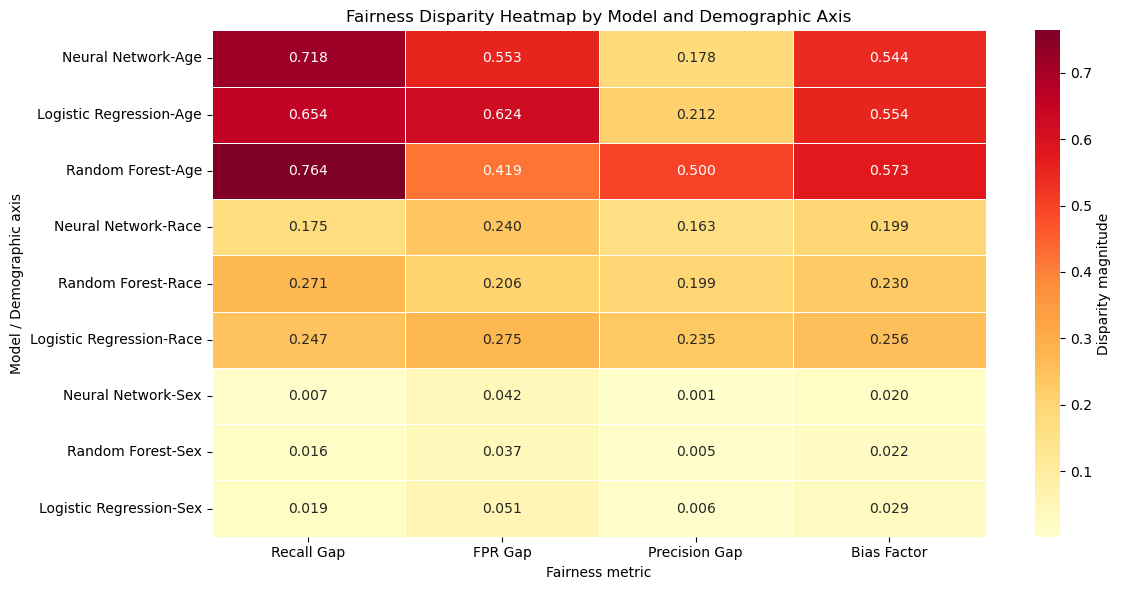


Bias Factor leaderboard (most fair at top for each axis/metric mix):
              Model Group Axis  Bias Factor
     Neural Network        Sex       0.0200
      Random Forest        Sex       0.0222
Logistic Regression        Sex       0.0294
     Neural Network       Race       0.1987
      Random Forest       Race       0.2304
Logistic Regression       Race       0.2559
     Neural Network        Age       0.5438
Logistic Regression        Age       0.5537
      Random Forest        Age       0.5733


In [20]:
# Build a compact fairness-disparity summary for visualization

model_group_tables = {
    ('Logistic Regression', 'Race'): race_fairness_lr,
    ('Logistic Regression', 'Sex'): sex_fairness_lr,
    ('Logistic Regression', 'Age'): age_fairness_lr,
    ('Random Forest', 'Race'): race_fairness_rf,
    ('Random Forest', 'Sex'): sex_fairness_rf,
    ('Random Forest', 'Age'): age_fairness_rf,
    ('Neural Network', 'Race'): race_fairness_nn,
    ('Neural Network', 'Sex'): sex_fairness_nn,
    ('Neural Network', 'Age'): age_fairness_nn,
}


def compute_disparity_row(df, model_name, group_axis):
    recall_gap = float(df['Recall'].max() - df['Recall'].min())
    fpr_gap = float(df['FPR'].max() - df['FPR'].min())
    precision_gap = float(df['Precision'].max() - df['Precision'].min())

    # Weighted fairness risk score; emphasize Recall and FPR gaps
    bias_factor = 0.4 * recall_gap + 0.4 * fpr_gap + 0.2 * precision_gap

    return {
        'Model': model_name,
        'Group Axis': group_axis,
        'Recall Gap': recall_gap,
        'FPR Gap': fpr_gap,
        'Precision Gap': precision_gap,
        'Bias Factor': bias_factor,
    }


disparity_rows = [
    compute_disparity_row(df, model_name, group_axis)
    for (model_name, group_axis), df in model_group_tables.items()
]

fairness_explain_df = pd.DataFrame(disparity_rows).sort_values(['Group Axis', 'Bias Factor'])

print('=' * 95)
print('FAIRNESS EXPLAINABILITY SUMMARY (Lower is better)')
print('=' * 95)
print(fairness_explain_df.round(4).to_string(index=False))
print('=' * 95)

# Heatmap: row = model, column = (group axis + metric)
heatmap_df = fairness_explain_df.set_index(['Model', 'Group Axis'])[
    ['Recall Gap', 'FPR Gap', 'Precision Gap', 'Bias Factor']
]

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Disparity magnitude'}
)
plt.title('Fairness Disparity Heatmap by Model and Demographic Axis')
plt.xlabel('Fairness metric')
plt.ylabel('Model / Demographic axis')
plt.tight_layout()
plt.show()

# Quick leaderboard using the new bias factor
bias_leaderboard = fairness_explain_df[['Model', 'Group Axis', 'Bias Factor']].sort_values('Bias Factor')
print('\nBias Factor leaderboard (most fair at top for each axis/metric mix):')
print(bias_leaderboard.round(4).to_string(index=False))